In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv("train.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [6]:
print("Shape of dataset:", df.shape)

Shape of dataset: (891, 12)


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [9]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [10]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features].copy()
y = df["Survived"]

In [11]:
print(df["Survived"].value_counts(normalize=True))

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [12]:
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

print(X.isnull().sum())

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [13]:
X = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

print(X.head())

   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


In [16]:
model = LogisticRegression(max_iter=1000)
_=model.fit(X_train,y_train);

In [17]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]


In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.8100558659217877
Model Accuracy (%): 81.00558659217877


In [19]:
y_probability = model.predict_proba(X_test)

print("Probability Predictions:")
print(y_probability[:10])

Probability Predictions:
[[0.89000888 0.10999112]
 [0.77786006 0.22213994]
 [0.86543114 0.13456886]
 [0.11373855 0.88626145]
 [0.26359019 0.73640981]
 [0.06875179 0.93124821]
 [0.31600646 0.68399354]
 [0.90921227 0.09078773]
 [0.24249543 0.75750457]
 [0.07816499 0.92183501]]


In [20]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Survival Probability": y_probability[:, 1]
})

print(results.head(10))

   Actual  Predicted  Survival Probability
0       1          0              0.109991
1       0          0              0.222140
2       0          0              0.134569
3       1          1              0.886261
4       1          1              0.736410
5       1          1              0.931248
6       1          1              0.683994
7       0          0              0.090788
8       1          1              0.757505
9       1          1              0.921835


In [21]:
new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Age": [22],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [7.25],
    "Sex_male": [1],
    "Embarked_Q": [0],
    "Embarked_S": [1]
})

prediction = model.predict(new_passenger)
probability = model.predict_proba(new_passenger)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.87258821 0.12741179]]


In [22]:
print("Passenger Details:")
print("Pclass: 3")
print("Age: 22")
print("SibSp: 0")
print("Parch: 0")
print("Fare: 7.25")
print("Sex: Male")
print("Embarked: Southampton")

if prediction[0] == 1:
    print("Prediction: SURVIVED")
else:
    print("Prediction: NOT SURVIVED")

Passenger Details:
Pclass: 3
Age: 22
SibSp: 0
Parch: 0
Fare: 7.25
Sex: Male
Embarked: Southampton
Prediction: NOT SURVIVED


In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[90 15]
 [19 55]]


In [24]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [25]:
print("Final Model Summary")
print("-------------------")
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])
print("Accuracy:", accuracy * 100, "%")

Final Model Summary
-------------------
Training Samples: 712
Testing Samples: 179
Accuracy: 81.00558659217877 %


In [26]:
actual_predicted = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

In [27]:
actual_predicted = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("========== ACTUAL VS PREDICTED ==========")
print(actual_predicted)

========== ACTUAL VS PREDICTED ==========
     Actual  Predicted
0         1          0
1         0          0
2         0          0
3         1          1
4         1          1
..      ...        ...
174       0          0
175       0          0
176       1          0
177       1          1
178       1          1

[179 rows x 2 columns]


In [28]:
probability_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_Not_Survived": y_probability[:, 0],
    "Probability_Survived": y_probability[:, 1]
})

print("========== PREDICTION RESULTS ==========")
print(probability_results)

========== PREDICTION RESULTS ==========
     Actual  Predicted  Probability_Not_Survived  Probability_Survived
0         1          0                  0.890009              0.109991
1         0          0                  0.777860              0.222140
2         0          0                  0.865431              0.134569
3         1          1                  0.113739              0.886261
4         1          1                  0.263590              0.736410
..      ...        ...                       ...                   ...
174       0          0                  0.854645              0.145355
175       0          0                  0.846527              0.153473
176       1          0                  0.644697              0.355303
177       1          1                  0.145915              0.854085
178       1          1                  0.301751              0.698249

[179 rows x 4 columns]


In [29]:
print("========== FEATURES USED BY THE MODEL ==========")
print(X.columns.tolist())

========== FEATURES USED BY THE MODEL ==========
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [30]:
new_prediction = model.predict(new_passenger)
new_probability = model.predict_proba(new_passenger)

print("========== NEW PASSENGER PREDICTION ==========")

if new_prediction[0] == 1:
    print("Prediction: Passenger is likely to SURVIVE")
else:
    print("Prediction: Passenger is likely to NOT SURVIVE")

print("Probability of NOT SURVIVING:", new_probability[0][0])
print("Probability of SURVIVING:", new_probability[0][1])

========== NEW PASSENGER PREDICTION ==========
Prediction: Passenger is likely to NOT SURVIVE
Probability of NOT SURVIVING: 0.8725882052152418
Probability of SURVIVING: 0.12741179478475817


In [31]:
print("========== PASSENGER DETAILS ==========")
print("Passenger Class:", new_passenger["Pclass"].iloc[0])
print("Age:", new_passenger["Age"].iloc[0])
print("Sex:", "Male" if new_passenger["Sex_male"].iloc[0] == 1 else "Female")
print("Fare:", new_passenger["Fare"].iloc[0])

print("\n========== FINAL PREDICTION ==========")

if new_prediction[0] == 1:
    print("The model predicts that the passenger would SURVIVE.")
else:
    print("The model predicts that the passenger would NOT SURVIVE.")

========== PASSENGER DETAILS ==========
Passenger Class: 3
Age: 22
Sex: Male
Fare: 7.25

========== FINAL PREDICTION ==========
The model predicts that the passenger would NOT SURVIVE.


========== CONFUSION MATRIX ==========
[[90 15]
 [19 55]]


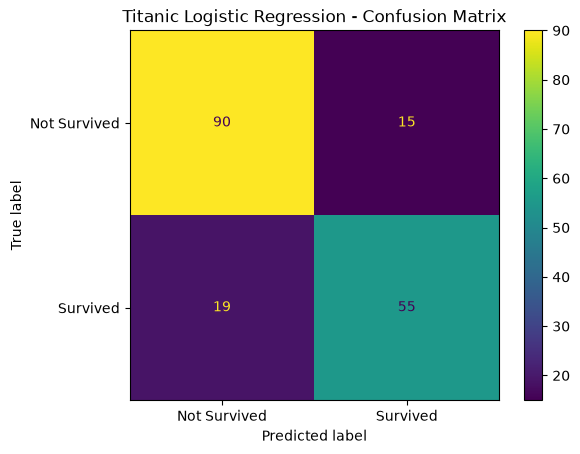

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("========== CONFUSION MATRIX ==========")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot()

plt.title("Titanic Logistic Regression - Confusion Matrix")
plt.show()

In [33]:
from sklearn.metrics import classification_report

print("========== CLASSIFICATION REPORT ==========")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Survived", "Survived"]
))

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       105
    Survived       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [34]:
print("==========================================")
print(" TITANIC LOGISTIC REGRESSION MODEL")
print("==========================================")

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])
print("Accuracy:", accuracy * 100, "%")

 TITANIC LOGISTIC REGRESSION MODEL
Training Samples: 712
Testing Samples: 179
Accuracy: 81.00558659217877 %
